In [2]:
from experiments_vllm import *
from data import *
from config_subject_skew import *

/home/dylan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
# Environment fixes
import os
os.environ["FLASHINFER_DISABLE_VERSION_CHECK"] = "1"

In [4]:
# Set seeds
seed = 43
torch.manual_seed(seed);

In [5]:
# Get data: generalize prompts and per-subject
print(subjects)
dataset_general = get_data_mmlu(n_samples=n_samples, shuffle_seed=seed)
datasets_subjects = [get_data_mmlu(n_samples=n_samples, shuffle_seed=seed, subset=s) for s in subjects]
prompts_general = format_prompts_mmlu(dataset_general)
prompts_subjects = [format_prompts_mmlu(d) for d in datasets_subjects]

['abstract_algebra']
Streaming cais/mmlu (all) (samples: 10)...
Streaming cais/mmlu (abstract_algebra) (samples: 10)...


In [6]:
# Get model
model, tokenizer = load_model(model_id, enable_bnb=True)
probe = MoEProbeMistral(model)

Loading checkpoint shards:   0%|          | 0/19 [00:00<?, ?it/s]

MoEHook: Scanning model for routers...
MoEHook: Attached probes to 32 router layers.
MoEHook: Model has 32 routers each with 8 experts and selects k=2 at each layer.


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
/home/dylan/.local/lib/python3.10/site-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
The attention mas

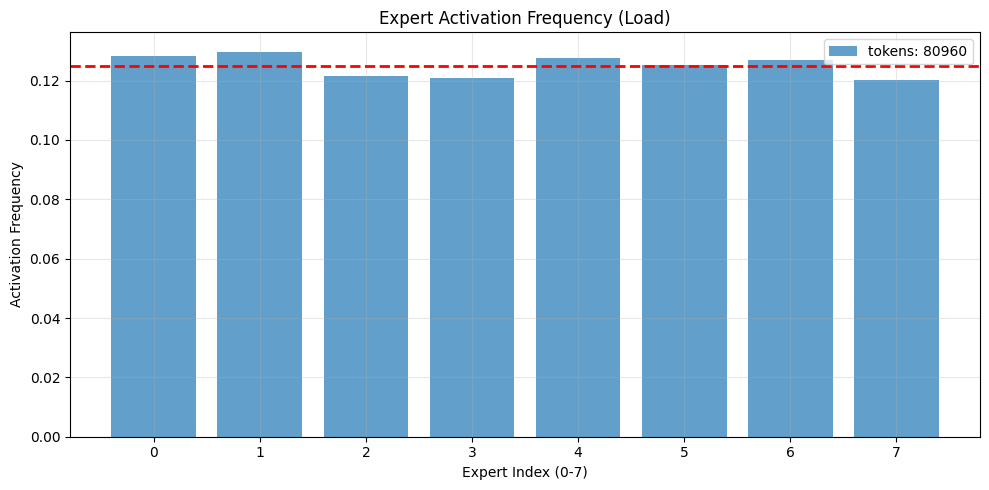

In [7]:
# Run some general prompts
for prompt in prompts_general:
    response, probs, active_experts = single_generate(model, tokenizer, probe=probe,
                                                      prompt=prompt, max_new_tokens=max_new_tokens,
                                                      clear_probe=False)
probe.plot_loadbalance(router_id=0)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
The attentio

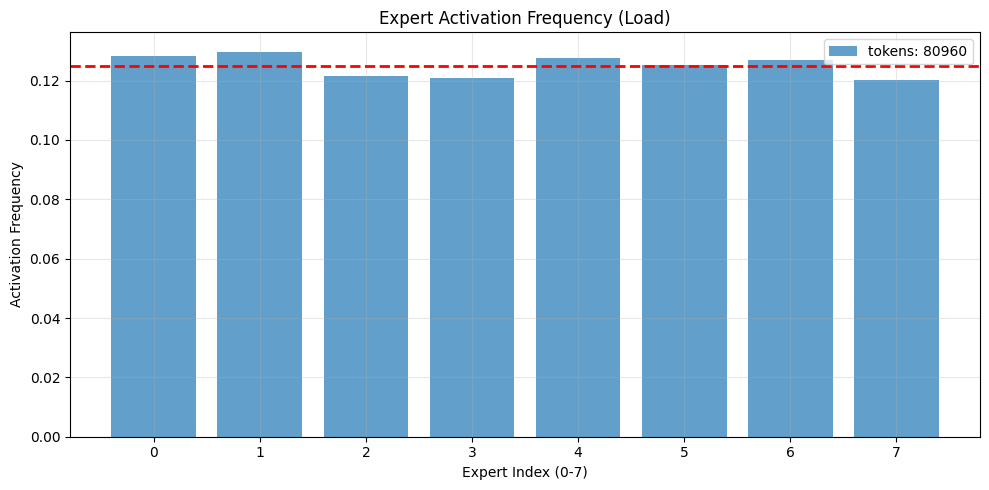

In [8]:
# Run some subject prompts
probe.clear()
for prompt in prompts_subjects[0]:
    response, probs, active_experts = single_generate(model, tokenizer, probe=probe,
                                                      prompt=prompt, max_new_tokens=max_new_tokens,
                                                      clear_probe=False)
probe.plot_loadbalance(router_id=0)

In [9]:
# Make trace directories
if not os.path.isdir(trace_path_general):
    os.mkdir(trace_path_general)
for p in trace_paths_subjects:
    if not os.path.isdir(p):
        os.mkdir(p)

In [10]:
# Run experiment over generalized MMLU questions
overall_results = await run_experiment_vllm_throughput(model_id,
                                                       prompts_general,
                                                       seed=seed,
                                                       max_new_tokens=max_new_tokens,
                                                       max_model_len=max_model_len,
                                                       batch_size=batch_size,
                                                       concurrency_limit=batch_size*4,
                                                       gpu_memory_utilization=gpu_memory_utilization,
                                                       n_gpus=n_gpus,
                                                       n_warmup_samples=n_warmup_samples,
                                                       print_output=False,
                                                       enable_expert_parallel=enable_expert_parallel,
                                                       enable_prefix_caching=enable_prefix_caching,
                                                       trace_dir=None)

Starting vLLM server for mistralai/Mixtral-8x7B-Instruct-v0.1...
Waiting for server to initialize ...


Traceback (most recent call last):
  File "/home/dylan/.local/bin/vllm", line 6, in <module>
    sys.exit(main())
  File "/home/dylan/.local/lib/python3.10/site-packages/vllm/entrypoints/cli/main.py", line 18, in main
    import vllm.entrypoints.cli.benchmark.main
  File "/home/dylan/.local/lib/python3.10/site-packages/vllm/entrypoints/cli/benchmark/main.py", line 10, in <module>
    from vllm.entrypoints.serve.utils.api_utils import VLLM_SUBCMD_PARSER_EPILOG
  File "/home/dylan/.local/lib/python3.10/site-packages/vllm/entrypoints/serve/utils/api_utils.py", line 20, in <module>
    from vllm.engine.arg_utils import EngineArgs
  File "/home/dylan/.local/lib/python3.10/site-packages/vllm/engine/arg_utils.py", line 36, in <module>
    from vllm.config import (
  File "/home/dylan/.local/lib/python3.10/site-packages/vllm/config/__init__.py", line 21, in <module>
    from vllm.config.model import (
  File "/home/dylan/.local/lib/python3.10/site-packages/vllm/config/model.py", line 30, in <m

An error occurred during inference: vLLM server process terminated unexpectedly.


In [11]:
# Run experiment over single MMLU subject
subject_results = await run_experiment_vllm_throughput(model_id,
                                                       prompts_subjects[0],
                                                       seed=seed,
                                                       max_new_tokens=max_new_tokens,
                                                       max_model_len=max_model_len,
                                                       batch_size=batch_size,
                                                       concurrency_limit=batch_size*4,
                                                       gpu_memory_utilization=gpu_memory_utilization,
                                                       n_gpus=n_gpus,
                                                       n_warmup_samples=n_warmup_samples,
                                                       print_output=False,
                                                       enable_expert_parallel=enable_expert_parallel,
                                                       enable_prefix_caching=enable_prefix_caching,
                                                       trace_dir=None)

Starting vLLM server for mistralai/Mixtral-8x7B-Instruct-v0.1...
Waiting for server to initialize ...


Traceback (most recent call last):
  File "/home/dylan/.local/bin/vllm", line 6, in <module>
    sys.exit(main())
  File "/home/dylan/.local/lib/python3.10/site-packages/vllm/entrypoints/cli/main.py", line 18, in main
    import vllm.entrypoints.cli.benchmark.main
  File "/home/dylan/.local/lib/python3.10/site-packages/vllm/entrypoints/cli/benchmark/main.py", line 10, in <module>
    from vllm.entrypoints.serve.utils.api_utils import VLLM_SUBCMD_PARSER_EPILOG
  File "/home/dylan/.local/lib/python3.10/site-packages/vllm/entrypoints/serve/utils/api_utils.py", line 20, in <module>
    from vllm.engine.arg_utils import EngineArgs
  File "/home/dylan/.local/lib/python3.10/site-packages/vllm/engine/arg_utils.py", line 36, in <module>
    from vllm.config import (
  File "/home/dylan/.local/lib/python3.10/site-packages/vllm/config/__init__.py", line 21, in <module>
    from vllm.config.model import (
  File "/home/dylan/.local/lib/python3.10/site-packages/vllm/config/model.py", line 30, in <m

An error occurred during inference: vLLM server process terminated unexpectedly.


In [12]:
# Save results
#import pickle
#with open(results_file_balanced, 'wb') as file:
#    pickle.dump(balanced_results, file)
#with open(results_file_imbalanced, 'wb') as file:
#    pickle.dump(imbalanced_results, file)